### Data Exploration

In [25]:
import pandas as pd
import numpy as np

train=pd.read_csv('./dataset/Train.csv')
test=pd.read_csv('./dataset/Test.csv')
mapping=pd.read_csv('./dataset/Mapping.csv')
train.head()

,Unnamed: 0,TEXT,Label
0,0,Vacation wasted ! #vacation2017 #photobomb #ti...,0
1,1,"Oh Wynwood, you’re so funny! : @user #Wynwood ...",1
2,2,Been friends since 7th grade. Look at us now w...,2
3,3,This is what it looks like when someone loves ...,3
4,4,RT @user this white family was invited to a Bl...,3


In [26]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  70000 non-null  int64 
 1   TEXT        70000 non-null  object
 2   Label       70000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.6+ MB


In [27]:
train.rename(columns={'TEXT': 'text', 'Label': 'label'}, inplace=True)
train.isnull().sum(), train.label.value_counts()


(Unnamed: 0    0
 text          0
 label         0
 dtype: int64,
 label
 9     15091
 2      7076
 3      6842
 7      4363
 15     3843
 13     3250
 16     2832
 17     2751
 1      2592
 11     2434
 14     2342
 6      2083
 8      1992
 5      1977
 12     1909
 4      1878
 19     1745
 18     1722
 10     1721
 0      1557
 Name: count, dtype: int64)

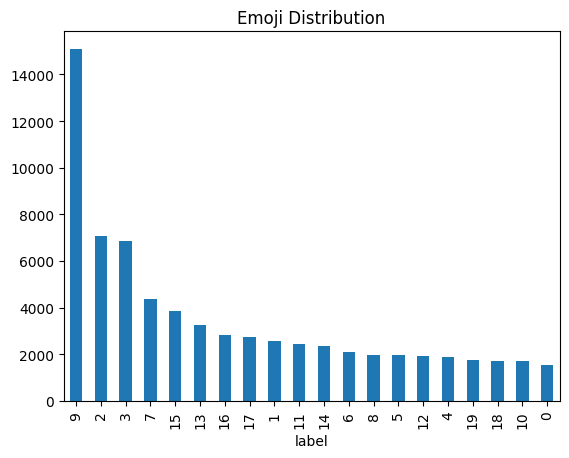

In [28]:
import matplotlib.pyplot as plt

train.label.value_counts().plot(kind='bar')
plt.title("Emoji Distribution")
plt.show()

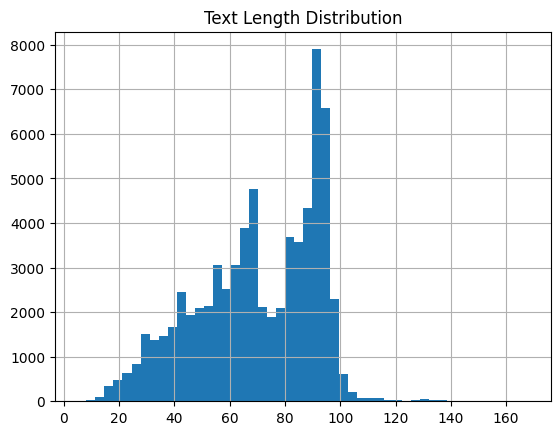

In [29]:
train['text_length'] = train.text.apply(len)

train['text_length'].hist(bins=50)
plt.title("Text Length Distribution")
plt.show()

In [30]:
mapping.head()

,Unnamed: 0,emoticons,number
0,0,😜,0
1,1,📸,1
2,2,😍,2
3,3,😂,3
4,4,😉,4


In [31]:
mapping.drop('Unnamed: 0', axis=1, inplace=True)
mapping.rename(columns={'emoticon': 'emoji', 'number': 'label'}, inplace=True)
train = train.merge(mapping, on='label', how='left')

train.head()

,Unnamed: 0,text,label,text_length,emoticons
0,0,Vacation wasted ! #vacation2017 #photobomb #ti...,0,93,😜
1,1,"Oh Wynwood, you’re so funny! : @user #Wynwood ...",1,88,📸
2,2,Been friends since 7th grade. Look at us now w...,2,97,😍
3,3,This is what it looks like when someone loves ...,3,90,😂
4,4,RT @user this white family was invited to a Bl...,3,101,😂


### Data Preprocessing

In [32]:
train.drop(['Unnamed: 0'], axis=1, inplace=True)

import re

def clean_text(text):
    text = text.lower()
    
    # remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # remove mentions
    text = re.sub(r'@\w+', '', text)
    
    # remove hashtags (keep text)
    text = re.sub(r'#', '', text)
    
    # remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

train['clean_text'] = train['text'].apply(clean_text)
train[['text', 'clean_text']].head()

,text,clean_text
0,Vacation wasted ! #vacation2017 #photobomb #ti...,vacation wasted vacation photobomb tired vacat...
1,"Oh Wynwood, you’re so funny! : @user #Wynwood ...",oh wynwood youre so funny wynwood art itwasam ...
2,Been friends since 7th grade. Look at us now w...,been friends since th grade look at us now we ...
3,This is what it looks like when someone loves ...,this is what it looks like when someone loves ...
4,RT @user this white family was invited to a Bl...,rt this white family was invited to a black ba...


In [33]:
import tensorflow as tf
from keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_size = 20000
max_len = 50

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(train['clean_text'])

X_train = tokenizer.texts_to_sequences(train['clean_text'])
X_train = pad_sequences(X_train, maxlen=max_len, padding='post')
X_train.shape

(70000, 50)

In [34]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [35]:
from sklearn.preprocessing import LabelEncoder
import pickle

le = LabelEncoder()

y_train = le.fit_transform(train['label'])

num_classes = len(le.classes_)
y_train = to_categorical(y_train, num_classes=num_classes)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

y_train[0]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.])

### Splitting data into Training and Validation sets

In [ ]:
# Handling class imbalance
# from sklearn.utils.class_weight import compute_class_weight
# import numpy as np

# class_weights = compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(y_train),
#     y=y_train
# )

# class_weights = dict(enumerate(class_weights))

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

### Building the LSTM Model with Self-Attention

In [37]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Bidirectional, Dropout, Attention, GlobalAveragePooling1D

vocab_size = 20000
embedding_dim = 128
max_len = 50
num_classes = 20

inputs = Input(shape=(max_len,))

# Embedding
x = Embedding(vocab_size, embedding_dim)(inputs)

# BiLSTM
lstm_out = Bidirectional(LSTM(128, return_sequences=True))(x)

# Attention (Self-Attention)
attention_out = Attention()([lstm_out, lstm_out])

# Combine LSTM + Attention
x = GlobalAveragePooling1D()(attention_out)

# Dense layers
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

In [38]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

### Training the Model

In [39]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    shuffle=True,
    # class_weight=class_weights
)

Epoch 1/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 85s 93ms/step - accuracy: 0.2215 - loss: 2.7096 - val_accuracy: 0.2426 - val_loss: 2.5856
Epoch 2/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 96s 110ms/step - accuracy: 0.2721 - loss: 2.5224 - val_accuracy: 0.2957 - val_loss: 2.4535
Epoch 3/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 76s 86ms/step - accuracy: 0.3173 - loss: 2.3654 - val_accuracy: 0.3065 - val_loss: 2.4292
Epoch 4/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 68s 78ms/step - accuracy: 0.3473 - loss: 2.2347 - val_accuracy: 0.3034 - val_loss: 2.4660
Epoch 5/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 69s 79ms/step - accuracy: 0.3727 - loss: 2.1130 - val_accuracy: 0.3039 - val_loss: 2.5290
Epoch 6/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 107s 122ms/step - accuracy: 0.3981 - loss: 1.9849 - val_accuracy: 0.2953 - val_loss: 2.6854
Epoch 7/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 108s 124ms/step - accuracy: 0.4282 - loss: 1.8501 - val_accuracy: 0.2925 - val_loss: 2.7574
Epoch 8/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 79s 90ms/step - accuracy: 0.4624 - loss: 1.71

In [40]:
model.save('emoji_prediction_model.keras')

### Testing

In [41]:
from tensorflow.keras.models import load_model

model = load_model("emoji_prediction_model.keras")

In [47]:
test = pd.read_csv("./dataset/Test.csv")
test.head()

,Unnamed: 0,id,TEXT
0,0,0,Thought this was cool...#Repost (get_repost)・・...
1,1,1,Happy 4th! Corte madera parade. #everytownusa ...
2,2,2,Luv. Or at least something close to it. @ Unio...
3,3,3,There's a slice of pie under that whipped crea...
4,5,5,#thankyou for your thank you We adore you both...


In [48]:
test.drop('Unnamed: 0', axis=1, inplace=True)

test.rename(columns={'TEXT': 'text','id':'label'}, inplace=True)

valid_labels = set(le.classes_)
test = test[test['label'].isin(valid_labels)]

test['clean_text'] = test['text'].apply(clean_text)

tokenizer = pickle.load(open("tokenizer.pkl", "rb"))
X_test = tokenizer.texts_to_sequences(test['clean_text'])
X_test = pad_sequences(X_test, maxlen=max_len, padding='post')

le=pickle.load(open("label_encoder.pkl", "rb"))
y_test = le.transform(test['label'])
num_classes = len(le.classes_)
y_test = to_categorical(y_test, num_classes=num_classes)


In [49]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.0667 - loss: 12.4531
Test Accuracy: 0.06666667014360428


In [51]:
import numpy as np
import pandas as pd

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

y_pred_labels = le.inverse_transform(y_pred_classes)
y_true_labels = le.inverse_transform(y_true_classes)

mapping = pd.read_csv('./dataset/Mapping.csv')
label_to_emoji = dict(zip(mapping['number'], mapping['emoticons']))

y_pred_emojis = [label_to_emoji[label] for label in y_pred_labels]
y_true_emojis = [label_to_emoji[label] for label in y_true_labels]

results = pd.DataFrame({
    "Text": test['text'],
    "Actual_Label": y_true_labels,
    "Predicted_Label": y_pred_labels,
    "Actual_Emoji": y_true_emojis,
    "Predicted_Emoji": y_pred_emojis
})

results.head(10)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


,Text,Actual_Label,Predicted_Label,Actual_Emoji,Predicted_Emoji
0,Thought this was cool...#Repost (get_repost)・・...,0,6,😜,📷
1,Happy 4th! Corte madera parade. #everytownusa ...,1,11,📸,🇺🇸
2,Luv. Or at least something close to it. @ Unio...,2,4,😍,😉
3,There's a slice of pie under that whipped crea...,3,2,😂,😍
4,#thankyou for your thank you We adore you both...,5,13,🎄,✨
5,the SPECIAL4U Lyric video will be posted on my...,6,10,📷,😁
6,Momma Tanya's In town ! Awesome dinner @user w...,7,6,🔥,📷
7,"Thing 1 and Thing 2 @ Huron, Ohio\n",8,15,😘,💕
8,Bday girl and some random @ Sheraton New York ...,10,2,😁,😍
9,Always fun with my forever wedding date Congra...,11,9,🇺🇸,❤


### Testing on custom text

In [52]:
max_len = 50

def predict_emoji(text):

    text = clean_text(text)

    seq = tokenizer.texts_to_sequences([text])

    padded = pad_sequences(seq, maxlen=max_len, padding='post')

    pred = model.predict(padded)
    pred_class = np.argmax(pred)

    original_label = le.inverse_transform([pred_class])[0]

    emoji = label_to_emoji.get(original_label, "❓")

    return emoji

In [66]:
print(predict_emoji("I am so happy today"))
print(predict_emoji("This is so funny"))
print(predict_emoji("I'm cool with it"))
print(predict_emoji("I love this so much"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
😍
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
😂
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
😎
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
❤
